# Goal

- Let us first look at the respective influence of the size of the training vs test set

In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [2]:
n_units=10
k_sub = 5
CONF = {
        "n_units": n_units,
        "n_families": 1,
        "latent_dim": 10,
        "k_sub": k_sub,
        "batch_size": 1024,
        "epochs": 10000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long),
        "init_means":[3.] # size must be n_families
    }

Ns_train = [2**i for i in [8,9,10,11,12,13,14,15,16]]
Ns_test = [2**i for i in [8,9,10,11,12,13]]

In [3]:
ents = []
stats=[]
for N_train in Ns_train:
    CONF['batch_size'] = N_train
    env,rec,loss_fn,optimize = initialize(CONF)
    stats.append(train(CONF,env,rec,loss_fn,optimize))
    ent=[]
    for N_test in Ns_test:
        ent.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))
    ents.append(ent)
ents = np.array(ents)

Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...
Training for 10000 epochs...


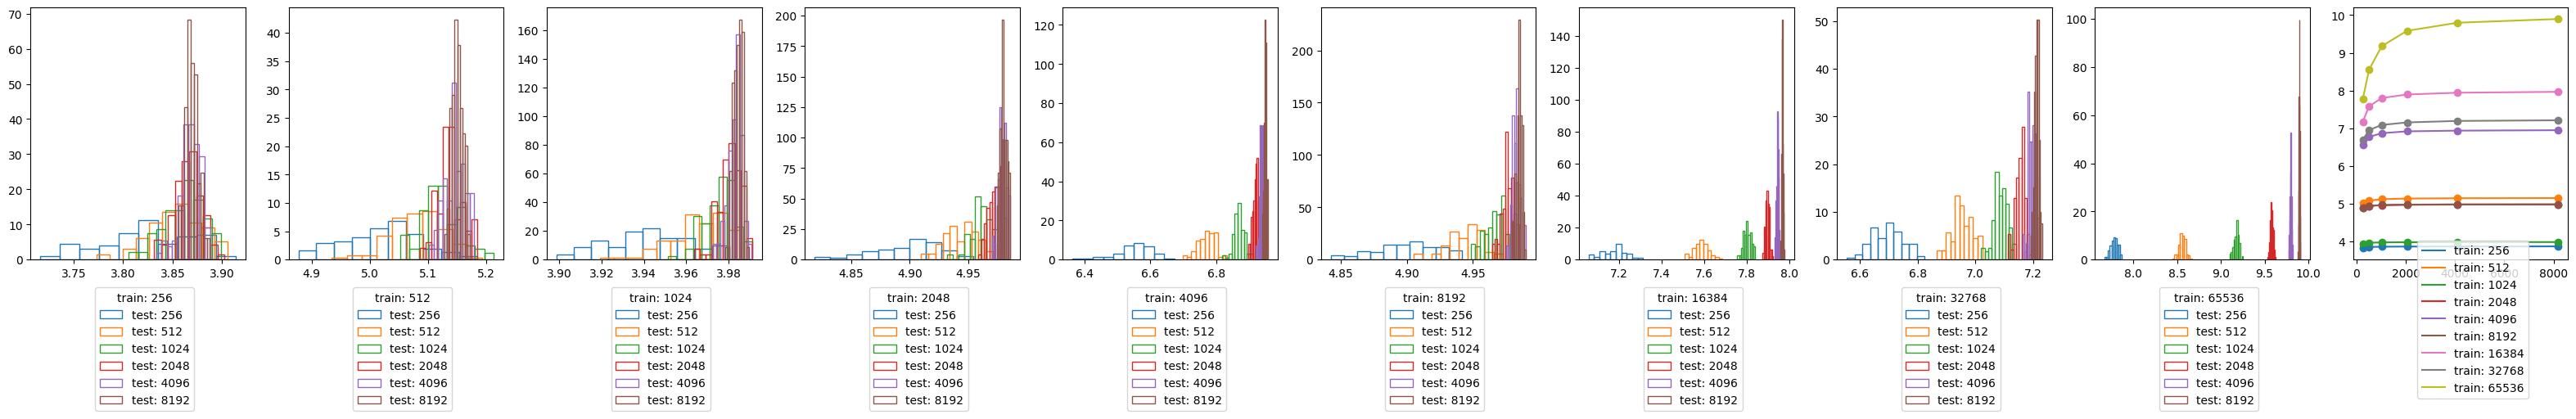

In [4]:
fig,ax = plt.subplots(ncols=ents.shape[0]+1,nrows=1,figsize = ((ents.shape[0]+1)*4,4))
prop_cycle = plt.rcParams['axes.prop_cycle']

for i in range(ents.shape[0]):
    colors = cycle(prop_cycle.by_key()['color'])
    for j in range(ents.shape[1]):
        ax[i].hist(ents[i,j],fill=False,edgecolor=next(colors),label = f'test: {Ns_test[j]}',density=True)
    ax[i].legend(loc=(0.3,-.6),title=f'train: {Ns_train[i]}')
    ax[-1].plot(Ns_test,np.mean(ents[i,:],axis=1),label=f'train: {Ns_train[i]}')
    ax[-1].scatter(Ns_test,np.mean(ents[i,:],axis=1))
ax[-1].legend(loc=(0.3,-0.55))

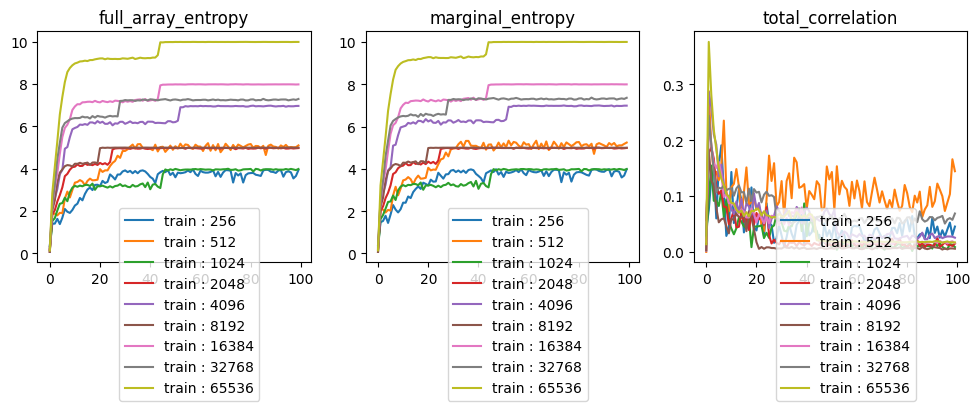

In [6]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
n=0
for stat in stats:    
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key],label=f'train : {Ns_train[n]}')
        ax[i].set_title(key)
    n+=1
for i in range(3):
    ax[i].legend(loc=(0.3,-.6))
#ax[2].set_ylim(0.1,0.6)

# Conclusion on the train/test size
First, we see that the larger the array, the harder it is to optimize. Obviously. first, looking at independant receptors, we see that 5 receptors is the largest we can do. Why:
- The size of the train test fixes the max entropy you can reach.
- Rule of thumb : when the test size is as large as the train, you got the max entropy.
- Increasing the training set increase the plateau height, which plateau when the train set is sufficiently high. At this point we assume that we reached the optimal for a given array.
- 5 indendant receptors is the max we can use before we observe the plateau of the plateau.


In [29]:
k_sub = 5
CONF = {
        "n_units": 1,
        "n_families": 1,
        "latent_dim": 10,
        "k_sub": k_sub,
        "batch_size": 2**16, #size of the training set
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[0,0,0,0,0]],dtype=torch.long),
        "init_means":[3.] # size must be n_families
    }

Ns_test = 2**13

Ns_sensors = np.arange(1,10,1)

In [30]:
ent=[]
stats = []
for N_sensors in Ns_sensors:
    # set the number of receptors in my array ALL INDEPENDANT HERE
    CONF['n_units'] = N_sensors
    CONF['receptor_indices'] = torch.tensor([[i for _ in range(k_sub)] for i in range(N_sensors)]) # # of receptors = # of units
    print(CONF['receptor_indices'])
    # 
    env,rec,loss_fn,optimize = initialize(CONF) # initialize
    stats.append(train(CONF,env,rec,loss_fn,optimize)) # train
    ent.append(test(CONF,env,rec,loss_fn,optimize,N_samples=CONF['batch_size'],indices = CONF['receptor_indices'])) # test
ent = np.array(ent)
stats = np.array(stats)

tensor([[0, 0, 0, 0, 0]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6]])
Training for 5000 epochs...
tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3

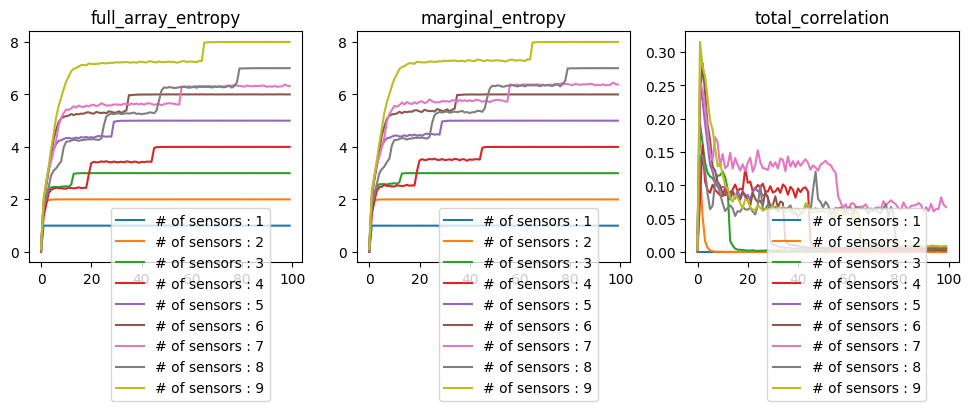

In [31]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
n=0
for stat in stats:    
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key],label=f'# of sensors : {Ns_sensors[n]}')
        ax[i].set_title(key)
    n+=1
for i in range(3):
    ax[i].legend(loc=(0.3,-.6))
#ax[2].set_ylim(0.1,0.6)

In [2]:
k_sub = 5
CONF = {
        "n_units": 1,
        "n_families": 1,
        "latent_dim": 10,
        "k_sub": k_sub,
        "batch_size": 2**14, #size of the training set
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[0,0,0,0,0]],dtype=torch.long),
        "init_means":[3.] # size must be n_families
    }

Ns_test = 2**13

Ns_units = [1,2,2,2,3,3,3,3,4]
Ns_units = np.arange(1,10,1)
Ns_sensors = np.arange(1,10,1)

Ns_sensor_corrected = np.array([[np.min([Ns_sensors[i],Ns_units[j]]) for i in range(Ns_sensors.shape[0])] for j in range(Ns_units.shape[0])])
print(Ns_sensor_corrected.shape)

(9, 9)


In [12]:
targets = {
    1: 'all', # Grabs [0,0,0,0,0], [1,1,1,1,1], [2,2,2,2,2]
    2: 5,     # k_1 (mixes 2 unique subunits)
    3: 0      # k_2 (mixes 3 unique subunits)
}
tensor_out = generate_targeted_receptors(n_units=5, k_sub=5, composition_targets=targets)
print(tensor_out)

tensor_out = generate_cascading_receptors(n_units=4, k_sub=5, n_sensors=3)
print(tensor_out)

tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [2, 2, 2, 3, 3],
        [0, 0, 0, 0, 3],
        [3, 3, 4, 4, 4],
        [0, 0, 0, 3, 3],
        [1, 2, 2, 2, 2]])
tensor([[2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [1, 1, 1, 1, 1]])


In [ ]:
ents_hetero=[]
stats_hetero = []

for N_unit in range(1,Ns_sensor_corrected.shape[0]):
    ent_hetero=[]
    stat_hetero=[]
    for N_sensor in Ns_sensor_corrected[N_unit]:
        # set the number of receptors in my array ALL INDEPENDANT HERE        
        CONF['n_units'] = N_unit
        CONF['receptor_indices'] =  generate_cascading_receptors(n_units=N_unit, k_sub=CONF['k_sub'], n_sensors=N_sensor)

        print(CONF)
        print()
        # 
        env,rec,loss_fn,optimize = initialize(CONF) # initialize
        stat_hetero.append(train(CONF,env,rec,loss_fn,optimize)) # train
        ent_hetero.append(test(CONF,env,rec,loss_fn,optimize,N_samples=CONF['batch_size'],indices = CONF['receptor_indices'])) # test
    ents_hetero.append(ent_hetero)
    stats_hetero.append(stat_hetero)
ents_hetero = np.array(ents_hetero)
stats_hetero = np.array(stats_hetero)

{'n_units': 1, 'n_families': 1, 'latent_dim': 10, 'k_sub': 5, 'batch_size': 16384, 'epochs': 5000, 'lr': 0.05, 'cov_weight': 10.0, 'n_bins': 2, 'bin_temp': 0.05, 'receptor_indices': tensor([[0, 0, 0, 0, 0]]), 'init_means': [3.0]}

Training for 5000 epochs...
{'n_units': 1, 'n_families': 1, 'latent_dim': 10, 'k_sub': 5, 'batch_size': 16384, 'epochs': 5000, 'lr': 0.05, 'cov_weight': 10.0, 'n_bins': 2, 'bin_temp': 0.05, 'receptor_indices': tensor([[0, 0, 0, 0, 0]]), 'init_means': [3.0]}

Training for 5000 epochs...
{'n_units': 1, 'n_families': 1, 'latent_dim': 10, 'k_sub': 5, 'batch_size': 16384, 'epochs': 5000, 'lr': 0.05, 'cov_weight': 10.0, 'n_bins': 2, 'bin_temp': 0.05, 'receptor_indices': tensor([[0, 0, 0, 0, 0]]), 'init_means': [3.0]}

Training for 5000 epochs...
{'n_units': 1, 'n_families': 1, 'latent_dim': 10, 'k_sub': 5, 'batch_size': 16384, 'epochs': 5000, 'lr': 0.05, 'cov_weight': 10.0, 'n_bins': 2, 'bin_temp': 0.05, 'receptor_indices': tensor([[0, 0, 0, 0, 0]]), 'init_means': 

IndexError: index 9 is out of bounds for axis 0 with size 9

In [9]:
print(ents_hetero.shape)
print(stats_hetero.shape)

(8, 9, 100)
(8, 9)


(0.1, 0.6)

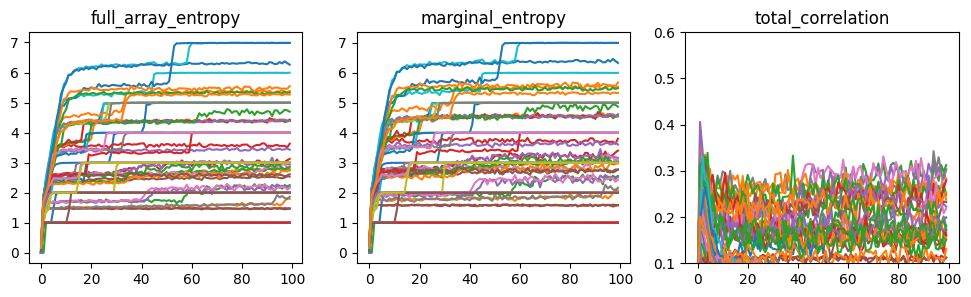

In [ ]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
n_unit = 0
for stats_h in stats_hetero:
    n_sensor=0
    for stat_h in stats_h:
        for i,key in enumerate(stat_h.keys()):
            ax[i].plot(stat_h[key],label=f'train : {Ns_sensor_corrected[n_unit,n_sensor]}')
            ax[i].set_title(key)
        n_sensor+=1
    n_unit+=1

#ax[2].legend(loc=(1.,0))
ax[2].set_ylim(0.1,0.6)

In [34]:
print(Ns_sensor_corrected.shape)
print(ents_hetero.shape)
print(Ns_sensor_corrected)

(9, 9)
(8, 9, 100)
[[1 1 1 1 1 1 1 1 1]
 [1 2 2 2 2 2 2 2 2]
 [1 2 3 3 3 3 3 3 3]
 [1 2 3 4 4 4 4 4 4]
 [1 2 3 4 5 5 5 5 5]
 [1 2 3 4 5 6 6 6 6]
 [1 2 3 4 5 6 7 7 7]
 [1 2 3 4 5 6 7 8 8]
 [1 2 3 4 5 6 7 8 9]]


Text(0, 0.5, 'MI')

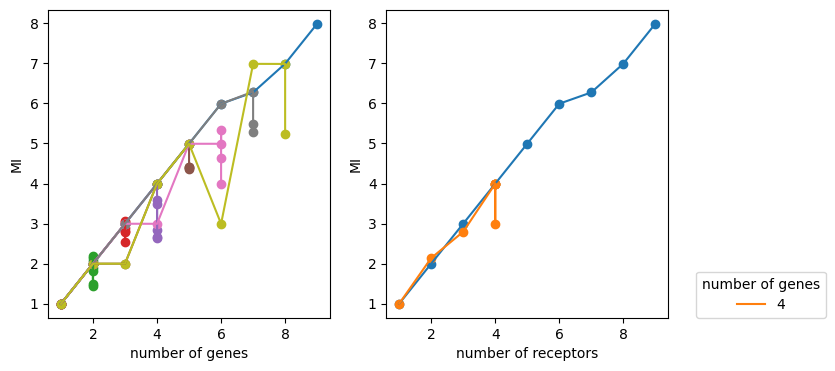

In [53]:
fig,ax = plt.subplots(ncols=2,nrows=1,figsize = ((2)*4,4))
prop_cycle = plt.rcParams['axes.prop_cycle']

ax[0].plot(Ns_sensors,np.mean(ent,axis=1))
ax[0].scatter(Ns_sensors,np.mean(ent,axis=1))
ax[1].plot(Ns_sensors,np.mean(ent,axis=1))
ax[1].scatter(Ns_sensors,np.mean(ent,axis=1))

for n_unit in range(Ns_sensor_corrected.shape[0]-1):
    #for N_sensor in Ns_sensor_corrected[n_unit]:
    ax[0].plot(Ns_sensor_corrected[n_unit],np.mean(ents_hetero[n_unit],axis=1))
    ax[0].scatter(Ns_sensor_corrected[n_unit],np.mean(ents_hetero[n_unit],axis=1))

#for n_sensor in range(Ns_sensor_corrected.shape[0]):
n_sensor=3
ax[1].plot(Ns_sensor_corrected[:-1,n_sensor],np.mean(ents_hetero[:,n_sensor],axis=1),label=n_sensor+1)
ax[1].scatter(Ns_sensor_corrected[:-1,n_sensor],np.mean(ents_hetero[:,n_sensor],axis=1))
ax[1].legend(loc=(1.1,0.),title='number of genes')
#ax.plot(Ns_units,np.mean(ent_hetero,axis=1))
#ax.scatter(Ns_units,np.mean(ent_hetero,axis=1))

ax[0].set_xlabel('number of genes')
ax[0].set_ylabel('MI')
ax[1].set_xlabel('number of receptors')
ax[1].set_ylabel('MI')
